# Markov (state-only) vs. age-dependent hazard: a quantitative comparison

This is an exploratory supplementary analysis: it checks a claim from
`pdf/manuscript_perspective.pdf` ("Old worms, new tricks: dynamical
instability explains late-life rejuvenation in C. elegans") against real
data, quantitatively rather than by eye.

## Background

The manuscript's Langevin model is **Markovian**: the rate of change of
the collective state `z` depends only on `z`'s current value, not on how
much calendar time has passed. The manuscript argues this is *why*
late-life DAF-2 depletion (the day-21 intervention) still extends
lifespan -- worms switched at day 21 behave like day-10-switched worms
once they reach the same state, regardless of the 11-day age gap. Its
Figure 2 supports this visually, with simulated trajectory insets showing
day-10 and day-21 dynamics that look indistinguishable.

"Look indistinguishable" is a visual read, not a quantitative one. This
notebook asks a more concrete, checkable question instead: does an
explicit age-dependent hazard (the classical Gompertz model) describe
the real survival data any better than our state-dependent Langevin
model does?

## What this notebook actually tests

The Markov property itself isn't something a simulation can test -- it's
a mathematical consequence of writing the drift/diffusion as functions of
`z` alone (no explicit `t`), true by construction for any parameter
values. What real data *can* test is a narrower, empirical question: does
our state-dependent model describe the observed survival curves at least
as well as a comparably-simple, purely age-dependent alternative? That
comparison is built below, in two parts:

1. **DMSO_day_10 (baseline, single phase).** Take our model's own fitted
   `(alpha, g, sigma)` for DMSO_day_10 directly from
   `0_auto_fit_parameters_mle.py` (not refit here). Fit a Gompertz hazard
   to the same data by maximum likelihood. Compare via AIC.
2. **DMSO_day_10 -> Auxin_day_21 (two phase, at the intervention).**
   `0_auto_fit_parameters_mle.py` does not fit Auxin_day_21 at all: our
   model's phase-2 dynamics there are exactly Auxin_day_10's own
   independently-fitted parameters, reused on the reasoning that worms
   switched onto auxin at day 21 settle into the same post-auxin dynamics
   as worms given auxin at day 10. The Gompertz counterpart mirrors this
   exactly: phase 1 fixed at Part 1's own DMSO Gompertz fit, phase 2
   fixed at a Gompertz model fit to Auxin_day_10's own data (fit fresh
   here). Neither model touches Auxin_day_21's data at all -- both make a
   genuine out-of-sample prediction for that condition, so `k=0` for both
   and the comparison reduces to a direct log-likelihood comparison.

Both parts use the *same* discrete-time, grouped-data likelihood
construction for both model families (interval probability mass for
deaths, survival probability for censoring -- see `_neg_log_lik_from_S`
below), so the two hazard shapes are judged on equal footing.

`delta_AIC` alone is a model-selection heuristic, not a significance
test with a p-value, and the two model families are non-nested (neither
is a restricted special case of the other), so a standard
likelihood-ratio test doesn't apply. Each part therefore also reports
**Vuong's (1989) closeness test**, the standard test for exactly this
non-nested setting, and a **Monte-Carlo noise check**: since the
Langevin model's likelihood is simulated (not closed-form like
Gompertz's), we confirm the observed AIC/logL gap is actually larger
than that simulation's own run-to-run noise.

## Why the Langevin model is Markovian

A stochastic process is Markovian if the distribution of its *next* step
depends only on its *current* state, not on how it got there or how much
calendar time has elapsed. Our model is `dz/dt = alpha*z + g*z^2 +
noise`, with `alpha`, `g` (`=alpha/Z`), and `sigma_sq` all *constants*
within a given phase -- the right-hand side is a function of `z` alone,
with no explicit `t` anywhere in it. Any Ito SDE `dz = b(z)dt +
sigma(z)dW` whose drift and diffusion depend only on the state defines a
time-homogeneous Markov process, by construction, so this property holds
for any parameter values -- it can't be falsified by simulation. What
data *can* speak to is whether this particular equation (rather than some
richer, `t`-dependent alternative) is an adequate description of the real
biology -- exactly the hazard-shape comparison run below.

One precise caveat about the switch: the two-phase model changes
`(alpha, g)` -- the two coefficients that actually define the drift
`dz/dt = alpha*z + g*z^2 + noise` -- at a fixed calendar day `t_switch`,
an exogenous, deterministic event (the actual day the intervention was
applied), not a hidden dependence of `z`'s own evolution on its history.
(`Z = alpha/g` and `z_m = sigma/sqrt(alpha)` are just derived quantities
of `(alpha, g, sigma)`, not independent parameters of the dynamics.)
Within each phase, conditional on which side of `t_switch` a worm is on,
the dynamics remain exactly Markovian in the sense above.

## Limitations

1. **Neither test directly validates the trajectory-level Markov claim.**
   `z` is never directly measured -- we only ever observe population
   death/censoring times. Any test built from survival data is a test of
   the *population-level hazard shape*, not of whether an individual
   worm's future genuinely depends only on its own current state.
2. **DMSO's mortality is only observed at 8 check-day ages**, with deaths
   compressed into the last four -- coarse enough that a hazard which
   plateaus *within* one of those gaps looks identical, in this data, to
   one that never plateaus. This limits how much either test's outcome
   can be over-read as evidence for or against a real late-life plateau.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import differential_evolution, minimize
from scipy.stats import norm

NOTEBOOK_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
SRC_DIR = NOTEBOOK_DIR.parent / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from data import kaplan_meier_curve, load_raw_survival_data
from model import km_from_fpt, simulate_fpt_and_state, simulate_two_phase

N_PATHS = 1_000_000  # simulated paths for the Langevin model's survival curve --
                      # a single simulation at this size, not several smaller
                      # ones averaged together (averaging finished logL values
                      # is biased low by Jensen's inequality, since logL is a
                      # concave -- log -- function of the simulated curve).
                      # The "Convergence check" section below sweeps N_PATHS
                      # from 20k to 1M for Auxin_day_21 -- its own borderline
                      # Vuong p-value drifts smoothly from 0.059 to 0.041 and
                      # has plateaued by ~500k, which is why this constant is
                      # set here rather than left at a smaller, faster-but-
                      # unconverged value.

raw_data = load_raw_survival_data()
for name, d in raw_data.items():
    print(f"{name}: n={d.n_total} worms, ages {d.t.min():.0f}-{d.t.max():.0f} days")

DMSO_day_10: n=232 worms, ages 10-25 days
Auxin_day_10: n=81 worms, ages 10-42 days
Auxin_day_21: n=247 worms, ages 10-39 days


## Shared likelihood machinery

Both model families are scored with the same grouped-data log-likelihood
construction used throughout this project
(`0_auto_fit_parameters_mle.py`'s `_weighted_neg_log_lik`): each observed
death at age `t_i` contributes the model's own interval probability mass
`S(t_(i-1)) - S(t_i)` (`t_(0)=0`, `S(0)=1`); each censored worm at `t_i`
contributes the model's survival probability `S(t_i)`. The two model
families differ only in how `S` is produced -- closed-form for Gompertz,
simulated for our Langevin model -- everything else about how a
log-likelihood is built from `S` is identical, so neither model gets an
easier scoring rule than the other.

`aic`, `report_fit`, and `report_delta_aic` below are the only functions
that print/format results -- Part 1 and Part 2 both call them instead of
each formatting its own `logL`/`k`/`AIC` output, so the two parts report
identically and can't drift apart.

In [2]:
def _grouped_death_censor_weights(d):
    """(t_unique, death_weight, censor_weight) for one GroupedSurvivalData."""
    t_unique = np.unique(d.t)
    death_weight = np.array([d.weight[(d.t == t) & (d.event_observed == 1)].sum() for t in t_unique])
    censor_weight = np.array([d.weight[(d.t == t) & (d.event_observed == 0)].sum() for t in t_unique])
    return t_unique, death_weight, censor_weight


def _log_lik_contributions_from_S(S_at_grid, death_weight, censor_weight, floor):
    """
    Per-observation-type log-likelihood values and their worm counts,
    given S already evaluated at `[0, t_unique...]`. Two "observation
    types" per age bin -- death (log interval probability mass) and
    censoring (log survival probability) -- returned flattened across
    both types and all bins as (values, weights). `sum(weights * values)`
    reproduces `_neg_log_lik_from_S`'s log-likelihood exactly; kept apart
    here because Vuong's test below needs the individual contributions,
    not just their sum.
    """
    S_at_grid = np.clip(S_at_grid, floor, 1.0)
    interval_mass = np.clip(S_at_grid[:-1] - S_at_grid[1:], floor, None)
    values = np.concatenate([np.log(interval_mass), np.log(S_at_grid[1:])])
    weights = np.concatenate([death_weight, censor_weight])
    return values, weights


def _neg_log_lik_from_S(S_at_grid, death_weight, censor_weight, floor):
    """
    Negative grouped-data log-likelihood given S already evaluated at
    `[0, t_unique...]` (so `S_at_grid[0] == 1` by construction).
    """
    values, weights = _log_lik_contributions_from_S(S_at_grid, death_weight, censor_weight, floor)
    log_lik = np.sum(weights * values)
    if not np.isfinite(log_lik):
        return np.inf
    return -float(log_lik)


def aic(logL, k):
    return 2 * k - 2 * logL


def report_fit(label, logL, k, note=""):
    """Print `label`'s logL/k/AIC in one consistent format and return its
    AIC -- used for every model/condition combination below so Part 1 and
    Part 2 report identically instead of each hand-rolling its own print."""
    suffix = f", {note}" if note else ""
    aic_val = aic(logL, k)
    print(f"{label}:  logL={logL:.4g}  (k={k}{suffix})  AIC={aic_val:.4g}")
    return aic_val


def report_delta_aic(condition, aic_gomp, aic_langevin):
    """Print + return AIC_Gompertz - AIC_Langevin for one condition, with
    the same 'favors X, |delta|>10 is decisive' framing used for every
    condition below."""
    delta = aic_gomp - aic_langevin
    print(f"\ndelta_AIC (Gompertz - Langevin), {condition} = {delta:+.4g}  "
          f"({'favors Langevin' if delta > 0 else 'favors Gompertz'}; "
          f"|delta_AIC| > 10 is conventionally read as decisive)")
    return delta

### Vuong's closeness test

`delta_AIC` says which model fits better and by how much, but not
whether that gap is statistically significant -- and since Langevin and
Gompertz are non-nested model families, the usual likelihood-ratio test
doesn't apply. Vuong's (1989) test is the standard test for exactly this
case: it treats each individual worm's log-likelihood contribution under
model A minus model B as one observation, and asks whether their mean is
significantly different from zero (AIC-corrected for the two models'
parameter counts), via a standard-normal `z`.

In [3]:
def vuong_test(S_a, S_b, d, k_a, k_b):
    """
    Vuong's (1989) closeness test between two models' fitted survival
    curves `S_a`, `S_b` (both evaluated at `[0, d`'s own observed
    ages`...]`, the same convention as `_neg_log_lik_from_S`) against the
    same real grouped data `d`. `k_a`/`k_b`: number of parameters each
    model estimated from *this* condition's own data (0 for a fixed/reused
    model, as in Part 2).

    Returns (z, p): z > 0 favors model a. This is the individual-worm
    generalization of `delta_AIC` -- AIC-corrected by `(k_a - k_b)`, same
    as `report_delta_aic` -- but standardized by the *spread* of
    per-worm log-likelihood differences instead of just their sum, which
    is what makes it an actual significance test rather than a bare
    magnitude comparison.
    """
    _, death_weight, censor_weight = _grouped_death_censor_weights(d)
    floor = 1.0 / (d.n_total + 1)
    values_a, weights = _log_lik_contributions_from_S(S_a, death_weight, censor_weight, floor)
    values_b, _ = _log_lik_contributions_from_S(S_b, death_weight, censor_weight, floor)

    n = weights.sum()
    lr = values_a - values_b
    lr_total = np.sum(weights * lr)
    lr_mean = lr_total / n
    lr_var = np.sum(weights * (lr - lr_mean) ** 2) / n

    z = (lr_total - (k_a - k_b)) / np.sqrt(n * lr_var)
    p = 2.0 * norm.sf(abs(z))
    return z, p


def report_vuong_test(condition, S_langevin, S_gompertz, d, k_langevin, k_gomp):
    """Run + print Vuong's test in the same format as report_delta_aic, plus
    the direct statistical conclusion its result licenses for this
    condition (see the Summary section's markdown for why these two
    conclusions -- not "the models are equivalent" -- are what a
    reject/fail-to-reject result actually supports)."""
    z, p = vuong_test(S_langevin, S_gompertz, d, k_langevin, k_gomp)
    sig = "significant at alpha=0.05" if p < 0.05 else "not significant at alpha=0.05"
    print(f"Vuong's test (Langevin vs. Gompertz), {condition}: z={z:+.3f}, p={p:.3g}  "
          f"({'favors Langevin' if z > 0 else 'favors Gompertz'}, {sig})")
    if p < 0.05:
        winner, loser = ("Langevin", "Gompertz") if z > 0 else ("Gompertz", "Langevin")
        print(f"  -> {winner} is significantly closer to the true generating process "
              f"than {loser} for {condition}.")
    else:
        print(f"  -> No significant evidence that either model is closer to the true "
              f"generating process for {condition}; Langevin is not shown to be "
              f"significantly different from Gompertz here.")
    return z, p

### Monte-Carlo noise in the Langevin model's simulated logL

Gompertz's likelihood is closed-form and exact; the Langevin model's is
estimated by simulating `n_paths` first-passage times, so it carries its
own Monte-Carlo noise that a single logL number doesn't reveal. Re-running
the same evaluation at several seeds and reporting the resulting spread
checks that the observed logL/AIC gap between the two models isn't
smaller than -- or an artifact of -- that simulation noise.

This is a *different* source of uncertainty from Vuong's test above, and
the two can look inconsistent at a glance without being so: the
Monte-Carlo check asks "how much would this one number jitter on a
rerun," while Vuong's test asks "how much does the per-worm advantage of
one model vary across the actual population" -- true biological
heterogeneity, not simulation noise. A large "N SEs" here alongside a
borderline Vuong `p` isn't a contradiction; it just means the aggregate
logL estimate itself is stable, while the two models' relative fit still
varies enough worm-to-worm that the population-level significance test
lands closer to the threshold.

Run at `n_paths=100_000` (not the production `N_PATHS=1_000_000` used
for the headline numbers) -- ten independent replicates at that size are
enough to characterize the *scale* of simulation noise, and doing so at
full production resolution would cost ten times as much for no added
information here.

In [4]:
def langevin_logL_monte_carlo_se(nll_fn, *args, n_seeds=10, base_seed=1000, **kwargs):
    """Mean and standard error of a Langevin nll_fn's logL across
    independent Monte-Carlo seeds (distinct from whatever seed the
    headline fit used, so this is a genuine independent-replicate check)."""
    logLs = np.array([-nll_fn(*args, seed=base_seed + i, **kwargs) for i in range(n_seeds)])
    return logLs.mean(), logLs.std(ddof=1)


def report_mc_noise(condition, logL_mean, logL_se, logL_gomp):
    """Print the Langevin logL's Monte-Carlo mean/SE and how many SEs the
    observed Langevin-vs-Gompertz logL gap spans -- context for whether
    that gap could plausibly be simulation noise."""
    gap = logL_mean - logL_gomp
    print(f"Langevin logL Monte-Carlo check, {condition}: mean={logL_mean:.4g}, SE={logL_se:.3g}  "
          f"(logL_Langevin - logL_Gompertz = {gap:+.4g}, {abs(gap) / logL_se:.1f} SEs)")

### Gompertz hazard model

Classical Gompertz hazard `M(t) = M0*exp(alpha_g*t)`, with closed-form
survival `S(t) = exp(-(M0/alpha_g)*(exp(alpha_g*t) - 1))` -- an explicit
function of calendar age, no state variable or mechanism at all.

The two-piece version does **not** restart the Gompertz clock at
`t_switch`: both `(M0_1, alpha_g1)` and `(M0_2, alpha_g2)` are always
evaluated at the worm's actual calendar age `t`, exactly as each was
fit (phase 1 against DMSO_day_10's own ages, phase 2 against
Auxin_day_10's own ages). For `t > t_switch`, phase 2's *own* survival
curve `S2(t)` is rescaled by `S1(t_switch) / S2(t_switch)` so `S` stays
continuous at the switch -- age is the shared "state" both phases refer
to, so switching hazard functions at a fixed age is the direct Gompertz
analogue of switching `(alpha, g)` at `t_switch` for a continuously
evolving `z` in the Langevin model. Resetting the clock to `t -
t_switch` instead would evaluate phase 2's curve over the wrong age
range entirely -- the near-flat, low-hazard *early* part of a curve fit
to ages 10-42, rather than the ages 21-39 actually being predicted.

In [5]:
def gompertz_survival(t, M0, alpha_g):
    t = np.asarray(t, dtype=float)
    return np.exp(-(M0 / alpha_g) * np.expm1(alpha_g * t))


def gompertz_survival_two_phase(t, M0_1, alpha_g1, M0_2, alpha_g2, t_switch):
    t = np.asarray(t, dtype=float)
    S1_at_switch = gompertz_survival(t_switch, M0_1, alpha_g1)
    S2_at_switch = gompertz_survival(t_switch, M0_2, alpha_g2)
    S = np.where(
        t <= t_switch,
        gompertz_survival(t, M0_1, alpha_g1),
        S1_at_switch * gompertz_survival(t, M0_2, alpha_g2) / S2_at_switch,
    )
    return S


def gompertz_neg_log_lik_two_phase(M0_1, alpha_g1, M0_2, alpha_g2, t_switch, d):
    """Negative log-likelihood of a *fixed* (not fit) two-phase Gompertz
    model against `d` -- the Gompertz counterpart of
    `langevin_neg_log_lik_two_phase` below, same signature shape, so Part 2
    can evaluate both model families identically."""
    t_unique, death_weight, censor_weight = _grouped_death_censor_weights(d)
    floor = 1.0 / (d.n_total + 1)
    S = gompertz_survival_two_phase(np.concatenate(([0.0], t_unique)), M0_1, alpha_g1, M0_2, alpha_g2, t_switch)
    return _neg_log_lik_from_S(S, death_weight, censor_weight, floor)


def _fit_two_stage(objective, bounds, seed):
    """Differential-evolution global search + Nelder-Mead local polish,
    the same two-stage pattern used for every fit in this project."""
    de_result = differential_evolution(objective, bounds, seed=seed, maxiter=200, popsize=20, polish=False)
    local_result = minimize(objective, x0=de_result.x, method="Nelder-Mead", bounds=bounds,
                             options={"xatol": 1e-6, "fatol": 1e-8, "maxiter": 2000})
    best_x = local_result.x if local_result.fun <= de_result.fun else de_result.x
    best_fun = min(local_result.fun, de_result.fun)
    return best_x, best_fun


def fit_gompertz_single(d, bounds, seed=0):
    """MLE fit of (M0, alpha_g) to one condition's grouped survival data."""
    t_unique, death_weight, censor_weight = _grouped_death_censor_weights(d)
    floor = 1.0 / (d.n_total + 1)

    def objective(params):
        M0, alpha_g = params
        S = gompertz_survival(np.concatenate(([0.0], t_unique)), M0, alpha_g)
        return _neg_log_lik_from_S(S, death_weight, censor_weight, floor)

    return _fit_two_stage(objective, bounds, seed)

### Our Langevin model's own likelihood

`S` is produced by simulating `n_paths` first-passage times from the
actual model (`model.simulate_fpt_and_state`/`simulate_two_phase`, the
same `beta=1` model used everywhere else in this project) and reading
its own Kaplan-Meier curve off those simulated paths -- no closed-form
approximation, so this is correct regardless of `gamma`.

The clipping `floor` passed to `_neg_log_lik_from_S` is `1/(d.n_total +
1)` -- the real cohort size, reflecting the real data's own statistical
resolution -- so both model families are scored against the same floor.

`langevin_survival_single`/`_two_phase` below return the simulated `S`
curve itself, factored out of the `_neg_log_lik` wrappers so Vuong's test
above (which needs the curve, not just its collapsed log-likelihood) can
reuse the exact same simulation.

In [6]:
def langevin_survival_single(alpha, Z, sigma_sq, d, n_paths=N_PATHS, dt=0.1, seed=0):
    """Simulated S(t) at [0, d's own observed ages...] under the
    single-phase Langevin model."""
    t_unique = np.unique(d.t)
    g = alpha / Z
    T, _, _ = simulate_fpt_and_state(
        n_paths, alpha, g, sigma_sq, Z, z0=0.0, dt=dt, t_max=t_unique[-1],
        rng=np.random.default_rng(seed),
    )
    return km_from_fpt(T, np.concatenate(([0.0], t_unique)), t_max=t_unique[-1])


def langevin_neg_log_lik_single(alpha, Z, sigma_sq, d, n_paths=N_PATHS, dt=0.1, seed=0):
    _, death_weight, censor_weight = _grouped_death_censor_weights(d)
    floor = 1.0 / (d.n_total + 1)
    S = langevin_survival_single(alpha, Z, sigma_sq, d, n_paths=n_paths, dt=dt, seed=seed)
    return _neg_log_lik_from_S(S, death_weight, censor_weight, floor)


def langevin_survival_two_phase(alpha0, Z0, alpha1, Z1, sigma_sq, t_switch, d,
                                 n_paths=N_PATHS, dt=0.1, seed=0):
    """Simulated S(t) at [0, d's own observed ages...] under the two-phase
    Langevin model. Builds its own seeded noise arrays for both phases --
    `simulate_two_phase` has no `rng` argument and silently falls back to a
    fixed internal seed when `noise1`/`noise2` aren't given, which would
    otherwise make `seed` here a no-op."""
    t_unique = np.unique(d.t)
    t_max = t_unique[-1]
    n_steps1 = int(round(t_switch / dt))
    n_steps2 = int(round((t_max - t_switch) / dt))
    noise1 = np.random.default_rng(seed).standard_normal((n_paths, n_steps1))
    noise2 = np.random.default_rng(seed + 1).standard_normal((n_paths, n_steps2))
    T = simulate_two_phase(
        n_paths, alpha0, Z0, alpha1, Z1, sigma_sq, t_switch, t_max, dt,
        noise1=noise1, noise2=noise2,
    )
    return km_from_fpt(T, np.concatenate(([0.0], t_unique)), t_max=t_max)


def langevin_neg_log_lik_two_phase(alpha0, Z0, alpha1, Z1, sigma_sq, t_switch, d,
                                    n_paths=N_PATHS, dt=0.1, seed=0):
    _, death_weight, censor_weight = _grouped_death_censor_weights(d)
    floor = 1.0 / (d.n_total + 1)
    S = langevin_survival_two_phase(alpha0, Z0, alpha1, Z1, sigma_sq, t_switch, d,
                                     n_paths=n_paths, dt=dt, seed=seed)
    return _neg_log_lik_from_S(S, death_weight, censor_weight, floor)

### Shared comparison plot

Part 1 and Part 2 each overlay the same three things on one axis -- the
real KM curve, the Langevin model's simulated curve, and the Gompertz
model's closed-form curve -- differing only in which condition, color,
and (for Part 2) an intervention-day marker. `plot_survival_comparison`
below draws that once, so the two parts can't silently drift out of sync
with each other.

In [7]:
def plot_survival_comparison(ax, kmf, t_plot, S_langevin, S_gompertz,
                              logL_langevin, logL_gompertz, color, title, t_switch=None):
    kmf.plot_survival_function(ax=ax, color=color, ci_show=False, label="real KM curve")
    ax.plot(t_plot, S_langevin, ls="--", color="black", label=f"Langevin model (logL={logL_langevin:.1f})")
    ax.plot(t_plot, S_gompertz, ls="-.", color="tab:red", label=f"Gompertz model (logL={logL_gompertz:.1f})")
    if t_switch is not None:
        ax.axvline(t_switch, color="gray", lw=1, ls=":", label=f"intervention start (day {t_switch:.0f})")
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("S(t)")
    ax.set_title(title)
    ax.legend(fontsize=8)

## Part 1: DMSO_day_10 baseline (single phase)

Our model's `(alpha, g, sigma)` are `0_auto_fit_parameters_mle.py`'s own
Step 1 fit for DMSO_day_10 (all 3 jointly estimated from this same
data, via Monte-Carlo MLE, subject to the plausibility constraints
described there) -- **not refit here**. `k=3` for the AIC below
reflects that these 3 parameters were estimated from DMSO_day_10's data,
even though we only evaluate (not re-optimize) them in this cell.

In [8]:
a0, log_g0, sigma0 = 0.1553, -2.5439, 1.5941  # 0_auto_fit_parameters_mle.py, Step 1
g0 = 10.0 ** log_g0
Z0 = a0 / g0
sigma_sq0 = sigma0 ** 2
print(f"Langevin (DMSO_day_10, from 0_auto_fit_parameters_mle.py): alpha={a0}, Z={Z0:.4g}, sigma_sq={sigma_sq0:.4g}")

d_dmso = raw_data["DMSO_day_10"]

nll_langevin1 = langevin_neg_log_lik_single(a0, Z0, sigma_sq0, d_dmso, seed=0)
logL_langevin1 = -nll_langevin1
k_langevin1 = 3
aic_langevin1 = report_fit("Langevin model", logL_langevin1, k_langevin1)

bounds_gompertz1 = [(1e-4, 2.0), (1e-3, 2.0)]
popt_gomp1, nll_gomp1 = fit_gompertz_single(d_dmso, bounds_gompertz1, seed=0)
M0_dmso, alpha_g_dmso = popt_gomp1
logL_gomp1 = -nll_gomp1
k_gomp1 = 2
print(f"Gompertz fit: M0={M0_dmso:.4g}, alpha_g={alpha_g_dmso:.4g}")
aic_gomp1 = report_fit("Gompertz model", logL_gomp1, k_gomp1)

delta_aic1 = report_delta_aic("DMSO_day_10", aic_gomp1, aic_langevin1)

S_langevin1_grid = langevin_survival_single(a0, Z0, sigma_sq0, d_dmso, seed=0)
S_gomp1_grid = gompertz_survival(np.concatenate(([0.0], np.unique(d_dmso.t))), M0_dmso, alpha_g_dmso)
z1, p1 = report_vuong_test("DMSO_day_10", S_langevin1_grid, S_gomp1_grid, d_dmso, k_langevin1, k_gomp1)

logL1_mc_mean, logL1_mc_se = langevin_logL_monte_carlo_se(
    langevin_neg_log_lik_single, a0, Z0, sigma_sq0, d_dmso, n_paths=100_000,
)
report_mc_noise("DMSO_day_10", logL1_mc_mean, logL1_mc_se, logL_gomp1)

Langevin (DMSO_day_10, from 0_auto_fit_parameters_mle.py): alpha=0.1553, Z=54.33, sigma_sq=2.541


Langevin model:  logL=-404.6  (k=3)  AIC=815.2
Gompertz fit: M0=0.0004378, alpha_g=0.3336
Gompertz model:  logL=-342.9  (k=2)  AIC=689.8

delta_AIC (Gompertz - Langevin), DMSO_day_10 = -125.4  (favors Gompertz; |delta_AIC| > 10 is conventionally read as decisive)


Vuong's test (Langevin vs. Gompertz), DMSO_day_10: z=-7.615, p=2.64e-14  (favors Gompertz, significant at alpha=0.05)
  -> Gompertz is significantly closer to the true generating process than Langevin for DMSO_day_10.


Langevin logL Monte-Carlo check, DMSO_day_10: mean=-404.9, SE=0.461  (logL_Langevin - logL_Gompertz = -62.05, 134.7 SEs)


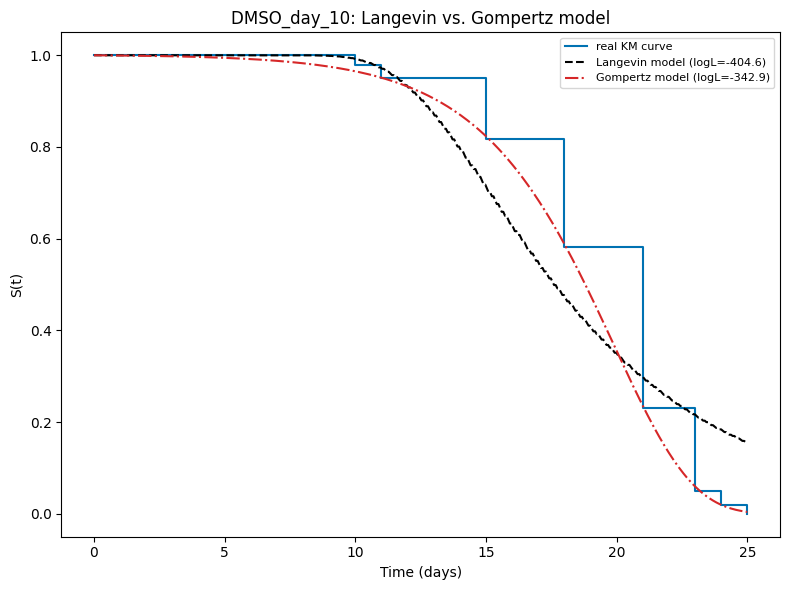

In [9]:
kmf_dmso = kaplan_meier_curve(d_dmso)
t_plot = np.linspace(0, d_dmso.t.max(), 400)
T_plot_sim1, _, _ = simulate_fpt_and_state(
    N_PATHS, a0, g0, sigma_sq0, Z0, z0=0.0, dt=0.1, t_max=d_dmso.t.max(), rng=np.random.default_rng(1),
)
S_langevin1_plot = km_from_fpt(T_plot_sim1, t_plot, t_max=d_dmso.t.max())
S_gomp1_plot = gompertz_survival(t_plot, M0_dmso, alpha_g_dmso)

fig, ax = plt.subplots(figsize=(8, 6))
plot_survival_comparison(ax, kmf_dmso, t_plot, S_langevin1_plot, S_gomp1_plot,
                          logL_langevin1, logL_gomp1, color="#0072B2",
                          title="DMSO_day_10: Langevin vs. Gompertz model")
plt.tight_layout()
plt.show()

## Part 2: DMSO_day_10 -> Auxin_day_21 (two phase, at the intervention)

`0_auto_fit_parameters_mle.py` does not fit Auxin_day_21 at all: our
model's phase-2 dynamics there are exactly Auxin_day_10's own
independently-fitted `(a0_auxin10, log_g0_auxin10)` (Step 1b), reused on
the reasoning that worms switched onto auxin at day 21 settle into the
same post-auxin dynamics as worms given auxin at day 10.

To keep this comparison matched, the Gompertz counterpart mirrors that
construction exactly: phase 1 fixed at Part 1's own DMSO Gompertz fit,
phase 2 fixed at a Gompertz model fit to Auxin_day_10's own data (fit
fresh here, since `0_auto_fit_parameters_mle.py` only fits our Langevin
model). **Neither model touches Auxin_day_21's data at all** -- both
make a genuine out-of-sample prediction for that condition, so `k=0` for
both and the comparison reduces to a direct log-likelihood comparison.

In [10]:
a0_auxin10, log_g0_auxin10 = 0.1035, -2.7358  # 0_auto_fit_parameters_mle.py, Step 1b
g0_auxin10 = 10.0 ** log_g0_auxin10
alpha1, Z1 = a0_auxin10, a0_auxin10 / g0_auxin10
t_switch = 21.0
print(f"Langevin phase 2 (= Auxin_day_10's own fit, from 0_auto_fit_parameters_mle.py): "
      f"alpha={alpha1:.4g}, Z={Z1:.4g}")

d_auxin10 = raw_data["Auxin_day_10"]
d_auxin21 = raw_data["Auxin_day_21"]

nll_langevin2 = langevin_neg_log_lik_two_phase(a0, Z0, alpha1, Z1, sigma_sq0, t_switch, d_auxin21, seed=0)
logL_langevin2 = -nll_langevin2
k_langevin2 = 0
aic_langevin2 = report_fit("Langevin model", logL_langevin2, k_langevin2,
                            note="both phases fixed -- neither fit to Auxin_day_21")

# Gompertz counterpart: phase 2 fixed at a fresh Gompertz fit to
# Auxin_day_10's own data, mirroring Step 1b -- never touching Auxin_day_21.
bounds_gompertz_a10 = [(1e-4, 2.0), (1e-3, 2.0)]
popt_gomp_a10, nll_gomp_a10 = fit_gompertz_single(d_auxin10, bounds_gompertz_a10, seed=1)
M0_2, alpha_g2 = popt_gomp_a10
print(f"Gompertz phase 2 (Auxin_day_10, fit fresh here): M0={M0_2:.4g}, alpha_g={alpha_g2:.4g}")

nll_gomp2 = gompertz_neg_log_lik_two_phase(M0_dmso, alpha_g_dmso, M0_2, alpha_g2, t_switch, d_auxin21)
logL_gomp2 = -nll_gomp2
k_gomp2 = 0
aic_gomp2 = report_fit("Gompertz model", logL_gomp2, k_gomp2,
                        note="both phases fixed -- neither fit to Auxin_day_21")

delta_aic2 = report_delta_aic("Auxin_day_21", aic_gomp2, aic_langevin2)

S_langevin2_grid = langevin_survival_two_phase(a0, Z0, alpha1, Z1, sigma_sq0, t_switch, d_auxin21, seed=0)
S_gomp2_grid = gompertz_survival_two_phase(
    np.concatenate(([0.0], np.unique(d_auxin21.t))), M0_dmso, alpha_g_dmso, M0_2, alpha_g2, t_switch,
)
z2, p2 = report_vuong_test("Auxin_day_21", S_langevin2_grid, S_gomp2_grid, d_auxin21, k_langevin2, k_gomp2)

logL2_mc_mean, logL2_mc_se = langevin_logL_monte_carlo_se(
    langevin_neg_log_lik_two_phase, a0, Z0, alpha1, Z1, sigma_sq0, t_switch, d_auxin21, n_paths=100_000,
)
report_mc_noise("Auxin_day_21", logL2_mc_mean, logL2_mc_se, logL_gomp2)

Langevin phase 2 (= Auxin_day_10's own fit, from 0_auto_fit_parameters_mle.py): alpha=0.1035, Z=56.33


Langevin model:  logL=-459.6  (k=0, both phases fixed -- neither fit to Auxin_day_21)  AIC=919.3
Gompertz phase 2 (Auxin_day_10, fit fresh here): M0=0.001912, alpha_g=0.15
Gompertz model:  logL=-442  (k=0, both phases fixed -- neither fit to Auxin_day_21)  AIC=884

delta_AIC (Gompertz - Langevin), Auxin_day_21 = -35.35  (favors Gompertz; |delta_AIC| > 10 is conventionally read as decisive)


Vuong's test (Langevin vs. Gompertz), Auxin_day_21: z=-2.042, p=0.0412  (favors Gompertz, significant at alpha=0.05)
  -> Gompertz is significantly closer to the true generating process than Langevin for Auxin_day_21.


Langevin logL Monte-Carlo check, Auxin_day_21: mean=-459.9, SE=0.36  (logL_Langevin - logL_Gompertz = -17.96, 49.9 SEs)


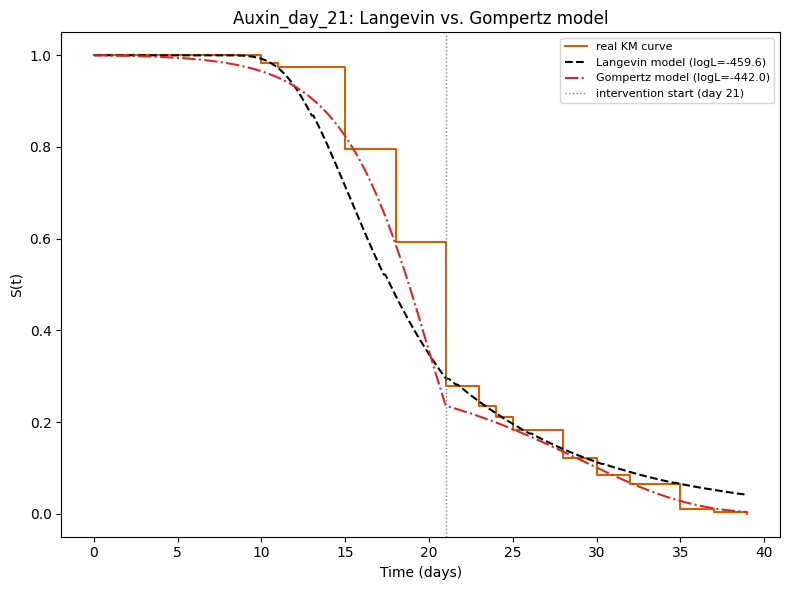

In [11]:
kmf_auxin21 = kaplan_meier_curve(d_auxin21)
t_plot21 = np.linspace(0, d_auxin21.t.max(), 400)
T_plot_sim2 = simulate_two_phase(
    N_PATHS, a0, Z0, alpha1, Z1, sigma_sq0, t_switch, d_auxin21.t.max(), dt=0.1,
)
S_langevin2_plot = km_from_fpt(T_plot_sim2, t_plot21, t_max=d_auxin21.t.max())
S_gomp2_plot = gompertz_survival_two_phase(t_plot21, M0_dmso, alpha_g_dmso, M0_2, alpha_g2, t_switch)

fig, ax = plt.subplots(figsize=(8, 6))
plot_survival_comparison(ax, kmf_auxin21, t_plot21, S_langevin2_plot, S_gomp2_plot,
                          logL_langevin2, logL_gomp2, color="#D55E00",
                          title="Auxin_day_21: Langevin vs. Gompertz model", t_switch=t_switch)
plt.tight_layout()
plt.show()

## Convergence check: does Vuong's test result depend on `N_PATHS`?

`N_PATHS` only controls how precisely `S(t)` is estimated for an
*already-fixed* `(alpha, Z, sigma)` -- it does not change the real
sample size (`n=247` worms) that governs Vuong's test's actual
statistical power. As `N_PATHS -> infinity`, the simulated curve
converges to the exact curve those fixed parameters imply, so `z`/`p`
should stabilize as `N_PATHS` grows, not drift systematically in one
direction. This sweeps `N_PATHS` directly for Auxin_day_21 -- the
borderline case -- rather than trusting a single run's realization.

 N_PATHS         z        p
   20000 -1.886033 0.059290
   50000 -1.903541 0.056970
  100000 -1.974519 0.048323
  200000 -2.012143 0.044205
  500000 -2.038871 0.041463
 1000000 -2.041880 0.041163


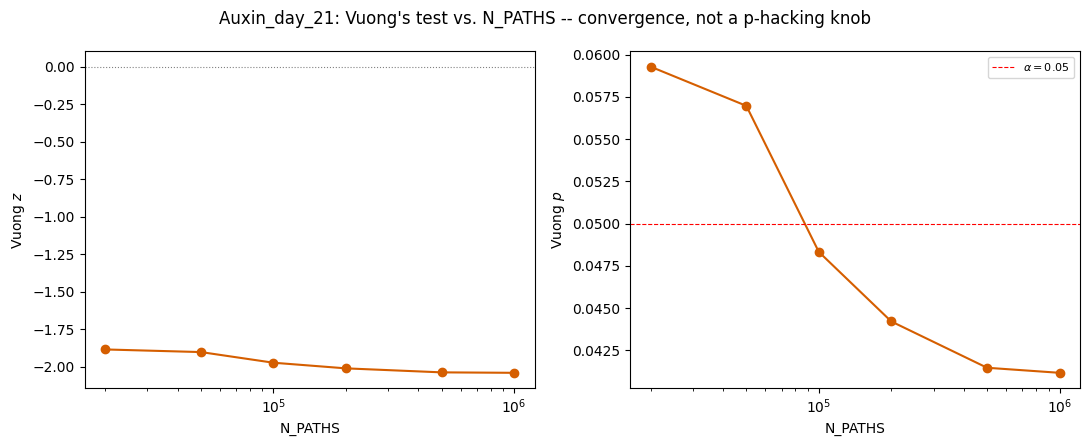

In [12]:
N_PATHS_SWEEP = [20_000, 50_000, 100_000, 200_000, 500_000, 1_000_000]

convergence_rows = []
for n_paths_i in N_PATHS_SWEEP:
    S_langevin_i = langevin_survival_two_phase(
        a0, Z0, alpha1, Z1, sigma_sq0, t_switch, d_auxin21, n_paths=n_paths_i, seed=0,
    )
    z_i, p_i = vuong_test(S_langevin_i, S_gomp2_grid, d_auxin21, k_langevin2, k_gomp2)
    convergence_rows.append({"N_PATHS": n_paths_i, "z": z_i, "p": p_i})

convergence_df = pd.DataFrame(convergence_rows)
print(convergence_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(convergence_df["N_PATHS"], convergence_df["z"], "o-", color="#D55E00")
axes[0].set_xscale("log")
axes[0].set_xlabel("N_PATHS")
axes[0].set_ylabel("Vuong $z$")
axes[0].axhline(0, color="gray", lw=0.8, ls=":")
axes[1].plot(convergence_df["N_PATHS"], convergence_df["p"], "o-", color="#D55E00")
axes[1].axhline(0.05, color="red", lw=0.8, ls="--", label=r"$\alpha=0.05$")
axes[1].set_xscale("log")
axes[1].set_xlabel("N_PATHS")
axes[1].set_ylabel("Vuong $p$")
axes[1].legend(fontsize=8)
fig.suptitle("Auxin_day_21: Vuong's test vs. N_PATHS -- convergence, not a p-hacking knob")
plt.tight_layout()
plt.show()

## Summary

Report both `delta_AIC` values above plainly, whichever way they land:
a per-condition result, not a single verdict on the model. Part 1 is a
direct fit-quality comparison on DMSO_day_10's own data; Part 2 is a
genuine out-of-sample prediction test for Auxin_day_21, with both models'
phase 1 and phase 2 parameters fixed from other conditions' own fits
(DMSO_day_10, Auxin_day_10) rather than fit to Auxin_day_21 itself --
a different, arguably stronger question than Part 1's single-phase
comparison. The Monte-Carlo noise check confirms each `delta_AIC` isn't
smaller than the Langevin model's own simulation noise.

**Interpreting Vuong's test result, per condition.** Vuong's `H0` is
"Langevin and Gompertz are equally close to the true generating
process" -- so its result is read directly, not just as a significance
flag on `delta_AIC`:

- **Rejecting `H0`** is a direct statistical statement that one model is
  significantly closer to the true generating process than the other.
- **Failing to reject `H0`** is the direct statistical statement that
  *there is no significant evidence that one model is closer to the
  true generating process than the other* -- i.e., the data do not
  establish that Gompertz explains that condition any better than
  Langevin does. This licenses saying Langevin "is not shown to be
  significantly different from Gompertz" for that condition, but not
  the stronger claim that the two models are equivalent (that would
  need a dedicated equivalence test, e.g. TOST against a pre-specified
  margin, not just a non-significant result here).

Either way, per the limitations noted at the top: this only ever tests
the *population-level hazard shape* against calendar age, not the
trajectory-level Markov claim itself (`z` is never directly measured),
and DMSO's coarse 8 check-day resolution limits how confidently either
outcome can be read as evidence for or against a real late-life
mortality plateau.

## Manuscript-ready outputs (Supplementary Note 2)

Renders the figure and table referenced by
`notebooks/notes/supplementary_note2_model_comparison.tex`, using the
manuscript's own plotting style (`2_pub_figures_auxin10_switch.py`'s
rcParams).

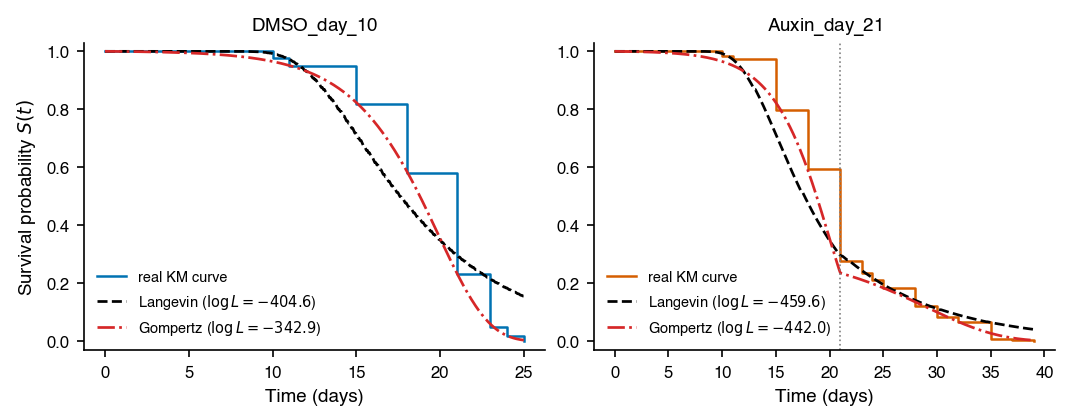

In [13]:
NOTES_DIR = NOTEBOOK_DIR / "notes"
NOTES_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.5,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "axes.grid": False,
})
cm = 1 / 2.54

fig_s2, axes_s2 = plt.subplots(1, 2, figsize=(18 * cm, 7 * cm))

axes_s2[0].step(kmf_dmso.survival_function_.index, kmf_dmso.survival_function_.iloc[:, 0],
                where="post", color="#0072B2", lw=1.2, label="real KM curve")
axes_s2[0].plot(t_plot, S_langevin1_plot, ls="--", color="black", lw=1.3,
                 label=rf"Langevin ($\log L={logL_langevin1:.1f}$)")
axes_s2[0].plot(t_plot, S_gomp1_plot, ls="-.", color="tab:red", lw=1.3,
                 label=rf"Gompertz ($\log L={logL_gomp1:.1f}$)")
axes_s2[0].set_title("DMSO$\\_$day$\\_$10")

axes_s2[1].step(kmf_auxin21.survival_function_.index, kmf_auxin21.survival_function_.iloc[:, 0],
                where="post", color="#D55E00", lw=1.2, label="real KM curve")
axes_s2[1].plot(t_plot21, S_langevin2_plot, ls="--", color="black", lw=1.3,
                 label=rf"Langevin ($\log L={logL_langevin2:.1f}$)")
axes_s2[1].plot(t_plot21, S_gomp2_plot, ls="-.", color="tab:red", lw=1.3,
                 label=rf"Gompertz ($\log L={logL_gomp2:.1f}$)")
axes_s2[1].axvline(t_switch, color="gray", lw=0.8, ls=":")
axes_s2[1].set_title("Auxin$\\_$day$\\_$21")

for ax in axes_s2:
    ax.set_xlabel("Time (days)")
    ax.set_ylim(-0.03, 1.03)
    ax.legend(loc="lower left")
axes_s2[0].set_ylabel("Survival probability $S(t)$")

fig_s2.tight_layout(pad=0.6)
fig_s2.savefig(NOTES_DIR / "supp_note2_fig.png", bbox_inches="tight", dpi=600)
plt.show()

In [14]:
supp2_rows = [
    {"Condition": "DMSO\\_day\\_10", "Model": "Langevin (this work)", "k": k_langevin1,
     "logL": logL_langevin1, "AIC": aic(logL_langevin1, k_langevin1),
     "Vuong z": "--", "Vuong p": "--"},
    {"Condition": "DMSO\\_day\\_10", "Model": "Gompertz", "k": k_gomp1,
     "logL": logL_gomp1, "AIC": aic(logL_gomp1, k_gomp1),
     "Vuong z": f"{z1:+.2f}", "Vuong p": f"{p1:.2g}"},
    {"Condition": "Auxin\\_day\\_21", "Model": "Langevin (this work)", "k": k_langevin2,
     "logL": logL_langevin2, "AIC": aic(logL_langevin2, k_langevin2),
     "Vuong z": "--", "Vuong p": "--"},
    {"Condition": "Auxin\\_day\\_21", "Model": "Gompertz", "k": k_gomp2,
     "logL": logL_gomp2, "AIC": aic(logL_gomp2, k_gomp2),
     "Vuong z": f"{z2:+.2f}", "Vuong p": f"{p2:.2g}"},
]
supp2_table = pd.DataFrame(supp2_rows).rename(columns={
    "logL": r"$\log L$", "AIC": "AIC", "k": "$k$", "Vuong z": "Vuong $z$", "Vuong p": "Vuong $p$",
})
latex_body2 = supp2_table.to_latex(index=False, escape=False, float_format="%.1f",
                                    column_format="llrrrrr")


def _vuong_conclusion_latex(condition, z, p):
    """Plain per-condition conclusion Vuong's result actually licenses --
    see the Summary section's markdown for why a non-significant result is
    phrased as 'not shown to be significantly different', not 'equivalent'."""
    if p < 0.05:
        winner = "Langevin" if z > 0 else "Gompertz"
        return (f"For {condition}, {winner} is significantly closer to the true "
                f"generating process ($p={p:.2g}$).")
    return (f"For {condition}, there is no significant evidence that either model is "
            f"closer to the true generating process ($p={p:.2g}$); Langevin is not "
            f"shown to be significantly different from Gompertz.")


latex_table2 = (
    "% Auto-generated by notebooks/99_markov_vs_age_dependent.py -- do not edit by hand.\n"
    "\\begin{table}[htbp]\n\\centering\n"
    + latex_body2
    + "\\caption{Grouped-data maximum-likelihood fit of our Langevin model "
      "(parameters from \\texttt{0\\_auto\\_fit\\_parameters\\_mle.py}, not "
      "refit here) versus a matched-complexity Gompertz hazard, per "
      "condition. For Auxin\\_day\\_21, both models' phase 1 and phase 2 "
      "parameters are fixed from other conditions' own fits "
      "(DMSO\\_day\\_10 for phase 1, Auxin\\_day\\_10 for phase 2), so "
      "$k=0$ parameters are estimated from Auxin\\_day\\_21's own data in "
      "either model -- a genuine out-of-sample prediction, not a fit. "
      r"$\Delta\mathrm{AIC} = \mathrm{AIC}_\mathrm{Gompertz} - "
      r"\mathrm{AIC}_\mathrm{Langevin} = " + f"{delta_aic1:+.1f}"
      r"$ (DMSO\_day\_10), $" + f"{delta_aic2:+.1f}"
      r"$ (Auxin\_day\_21); negative values favor Gompertz. Vuong $z$/$p$ "
      "(reported on the Gompertz row of each condition, testing that "
      "condition's Langevin-vs-Gompertz pair) is Vuong's (1989) "
      "closeness test, AIC-corrected for $k$; $z>0$ favors Langevin. "
      + _vuong_conclusion_latex("DMSO\\_day\\_10", z1, p1) + " "
      + _vuong_conclusion_latex("Auxin\\_day\\_21", z2, p2) + "}"
      "\n\\label{tab:supp_note2_model_comparison}\n\\end{table}\n"
)
(NOTES_DIR / "supp_note2_table.tex").write_text(latex_table2)
print(latex_table2)

% Auto-generated by notebooks/99_markov_vs_age_dependent.py -- do not edit by hand.
\begin{table}[htbp]
\centering
\begin{tabular}{llrrrrr}
\toprule
Condition & Model & $k$ & $\log L$ & AIC & Vuong $z$ & Vuong $p$ \\
\midrule
DMSO\_day\_10 & Langevin (this work) & 3 & -404.6 & 815.2 & -- & -- \\
DMSO\_day\_10 & Gompertz & 2 & -342.9 & 689.8 & -7.61 & 2.6e-14 \\
Auxin\_day\_21 & Langevin (this work) & 0 & -459.6 & 919.3 & -- & -- \\
Auxin\_day\_21 & Gompertz & 0 & -442.0 & 884.0 & -2.04 & 0.041 \\
\bottomrule
\end{tabular}
\caption{Grouped-data maximum-likelihood fit of our Langevin model (parameters from \texttt{0\_auto\_fit\_parameters\_mle.py}, not refit here) versus a matched-complexity Gompertz hazard, per condition. For Auxin\_day\_21, both models' phase 1 and phase 2 parameters are fixed from other conditions' own fits (DMSO\_day\_10 for phase 1, Auxin\_day\_10 for phase 2), so $k=0$ parameters are estimated from Auxin\_day\_21's own data in either model -- a genuine out-of-sampl